In [2]:
# Imports
import pandas as pd
import numpy as np

# Fin Data Sources
import yfinance as yf
import pandas_datareader as pdr

# Data Visualization
import plotly.graph_objs as go
import plotly.express as px

import time
from datetime import date

# 1) Understanding Data-Driven Decisions data pulls

In [3]:
end = date.today()
print(f'Year = {end.year}, month = {end.month}, day = {end.day}')

start = date(year = end.year - 70, month = end.month, day = end.day)
print(f'Period for indexes: {start} to {end}')

Year = 2026, month = 9, day = 11
Period for indexes: 1956-09-11 to 2026-09-11


## 1.1) GDP

In [4]:
# Real Potential Gross Domestic Product (GDPPOT) - FRED
# Billions of Chained 2012 Dollars, Quarterly
gdppot = pdr.DataReader('GDPPOT', 'fred', start=start)

In [5]:
# Calculate YoY and QoQ growth rates which are yearly and quarterly growth rates respectively
gdppot["gdppot_us_yoy"] = gdppot.GDPPOT/gdppot.GDPPOT.shift(4) - 1
gdppot["gdppot_us_qoq"] = gdppot.GDPPOT/gdppot.GDPPOT.shift(1) - 1
gdppot.tail(15)

,GDPPOT,gdppot_us_yoy,gdppot_us_qoq
DATE,,,
2023-01-01,22229.482194,0.025405,0.006551
2023-04-01,22377.867950,0.026085,0.006675
2023-07-01,22527.570931,0.026560,0.006690
2023-10-01,22678.156520,0.026867,0.006685
2024-01-01,22828.945411,0.026967,0.006649
2024-04-01,22979.033391,0.026864,0.006574
2024-07-01,23126.896106,0.026604,0.006435
2024-10-01,23271.541687,0.026165,0.006254
2025-01-01,23414.656420,0.025657,0.006150


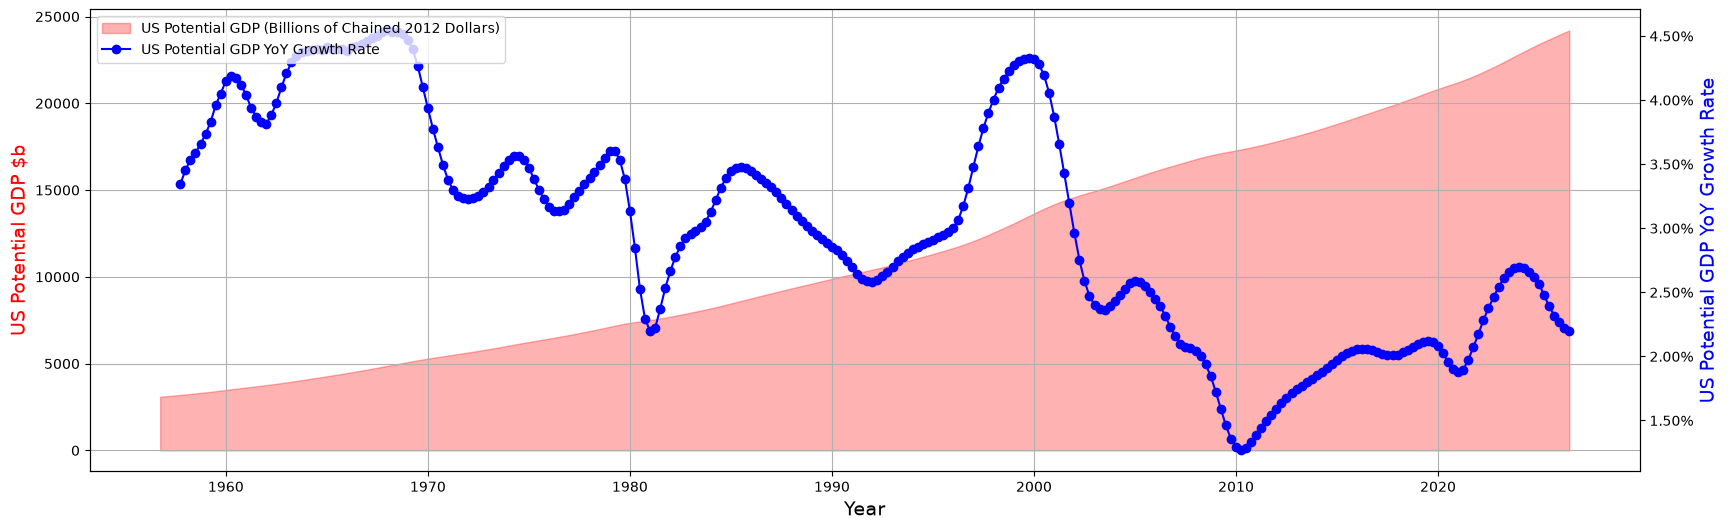

In [6]:
# Visuals GDPPOT

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

fig, ax = plt.subplots(figsize=(20, 6))
plt.grid(True)

# Plotting area under US potential GDP curve
ax.fill_between(gdppot.index, gdppot.GDPPOT, color='red', alpha=0.3, label='US Potential GDP (Billions of Chained 2012 Dollars)')

# Creating a secondary y-axis for GDP growth percentage
ax2 = ax.twinx()
ax2.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))
ax2.plot(gdppot.gdppot_us_yoy, color='blue', marker='o', label='US Potential GDP YoY Growth Rate')

# Setting labels and title
ax.set_xlabel('Year', fontsize=14)
ax.set_ylabel('US Potential GDP $b', color='red', fontsize=14)
ax2.set_ylabel('US Potential GDP YoY Growth Rate', color='blue', fontsize=14)

# Adding legends
lines, labels = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc='upper left')

plt.show() 

## 1.2) Inflation - CPI Core

In [7]:
# Core CPI index, MONTHLY
# The "Consumer Price Index for All Urban Consumers: All Items Less Food & Energy"
# is an aggregate of prices paid by urban consumers for a typical basket of goods, excluding food and energy.
# This measurement, known as "Core CPI," is widely used by economists because food and energy have very volatile prices.
cpilfesl = pdr.DataReader('CPILFESL', 'fred', start=start)

In [8]:
cpilfesl.head()

,CPILFESL
DATE,
1957-01-01,28.5
1957-02-01,28.6
1957-03-01,28.7
1957-04-01,28.8
1957-05-01,28.8


In [9]:
# Core CPI index, MONTHLY
cpilfesl['cpi_core_yoy'] = cpilfesl.CPILFESL/cpilfesl.CPILFESL.shift(12) - 1
cpilfesl['cpi_core_mom'] = cpilfesl.CPILFESL/cpilfesl.CPILFESL.shift(1) - 1

cpilfesl.tail(13)

,CPILFESL,cpi_core_yoy,cpi_core_mom
DATE,,,
2025-07-01,328.682,0.030545,0.003125
2025-08-01,329.700,0.031118,0.003097
2025-09-01,330.418,0.030200,0.002178
2025-10-01,NaN,NaN,NaN
2025-11-01,331.043,0.025990,NaN
2025-12-01,331.814,0.026465,0.002329
2026-01-01,332.793,0.025120,0.002950
2026-02-01,333.512,0.024725,0.002161
2026-03-01,334.165,0.026022,0.001958


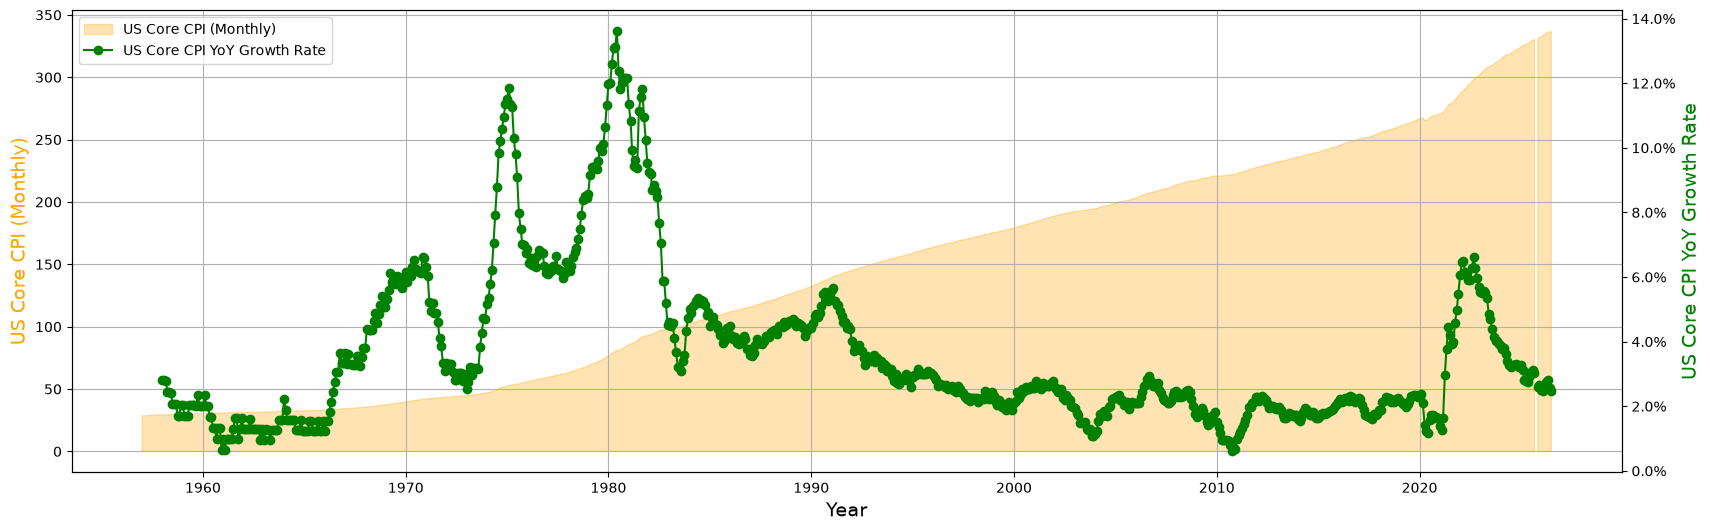

In [11]:
fig, ax = plt.subplots(figsize=(20, 6))
plt.grid(True)

# Plotting area under US Core CPI curve
ax.fill_between(cpilfesl.index, cpilfesl.CPILFESL, color='orange', alpha = 0.3, label='US Core CPI (Monthly)')

# Creating a secondary y-axis for Core CPI growth percentage
ax2 = ax.twinx()
ax2.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))
ax2.plot(cpilfesl.cpi_core_yoy, color='green', marker='o', label='US Core CPI YoY Growth Rate')

# Setting labels and title
ax.set_xlabel('Year', fontsize=14)
ax.set_ylabel('US Core CPI (Monthly)', color='orange', fontsize=14)
ax2.set_ylabel('US Core CPI YoY Growth Rate', color='green', fontsize=14)

# Adding legends
lines, labels = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc='upper left')

plt.show()

## 1.3 Interest rates

In [12]:
# Fed rate, which is the Federal Funds Target Rate
fedfunds = pdr.DataReader('FEDFUNDS', 'fred', start=start)
fedfunds.tail(10)

,FEDFUNDS
DATE,
2025-11-01,3.88
2025-12-01,3.72
2026-01-01,3.64
2026-02-01,3.64
2026-03-01,3.64
2026-04-01,3.64
2026-05-01,3.63
2026-06-01,3.63
2026-07-01,3.63


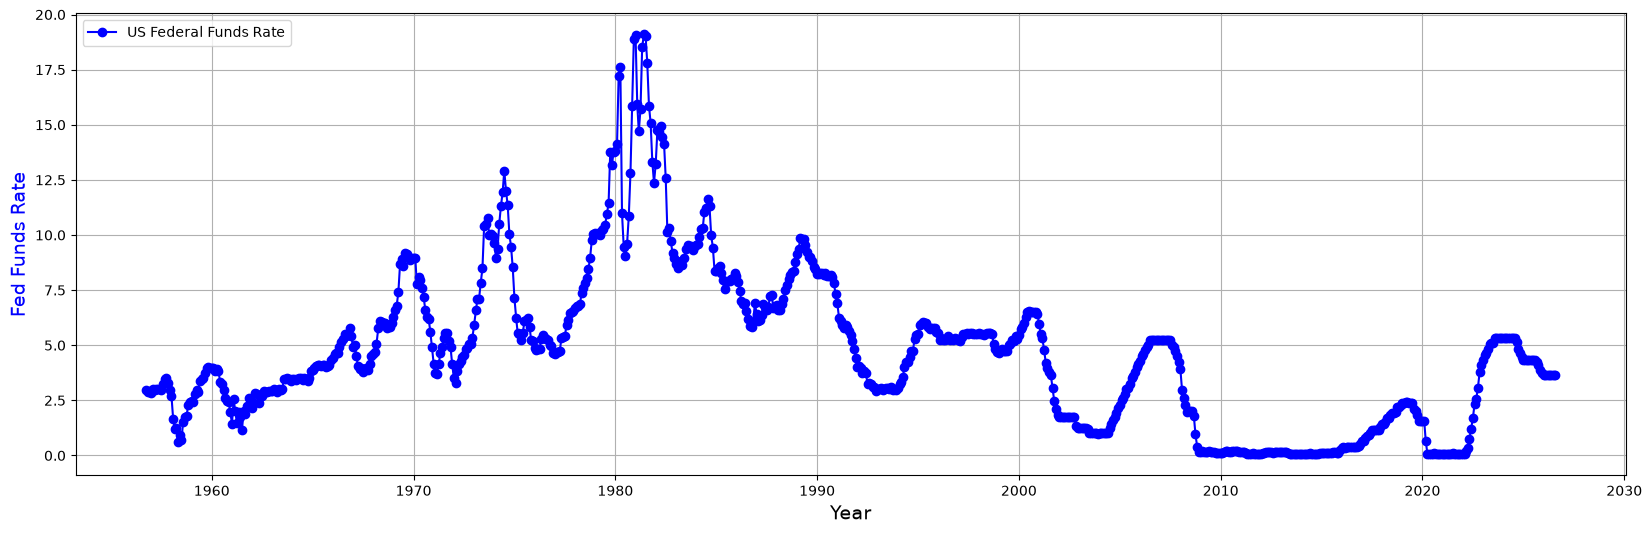

In [18]:
# Fed Funds
fig, ax = plt.subplots(figsize=(20, 6))
plt.grid(True)

# Plotting area under US Potential GDP curve
# ax.fill_between(fedfunds.index, fedfunds.FEDFUNDS, color='orange', alpha = 0.3, label='Core CPI Index (Monthly)')

# Creating a secondary y-axis for Fed Funds Rate
# ax2 = ax.twinx()
ax.plot(fedfunds.FEDFUNDS, color='blue', marker='o', label='US Federal Funds Rate')

# Setting labels and title
ax.set_xlabel('Year', fontsize=14)
ax.set_ylabel("Fed Funds Rate", color="blue", fontsize=14)

# Adding legends
lines, labels = ax.get_legend_handles_labels()
ax.legend(lines, labels, loc='upper left')

plt.show()

In [19]:
# https://fred.stlouisfed.org/series/DGS1
dgs1 = pdr.DataReader('DGS1', 'fred', start=start)
dgs1.tail()

,DGS1
DATE,
2026-09-03,4.11
2026-09-04,4.13
2026-09-07,NaN
2026-09-08,4.15
2026-09-09,4.17


In [20]:
dgs5 = pdr.DataReader('DGS5', 'fred', start=start)
dgs5.tail()

,DGS5
DATE,
2026-09-03,4.52
2026-09-04,4.54
2026-09-07,NaN
2026-09-08,4.57
2026-09-09,4.61


## 1.4 SNP500

In [21]:
import yfinance as yf

# SPX = S&P 500
ticker_obj = yf.Ticker("^SPX")
spx_index = ticker_obj.history(start=start, end=end)
spx_index.tail()

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2026-09-03 00:00:00-04:00,7686.709961,7756.759766,7686.709961,7747.709961,4726400000,0.0,0.0
2026-09-04 00:00:00-04:00,7750.189941,7750.189941,7706.120117,7718.600098,4103570000,0.0,0.0
2026-09-08 00:00:00-04:00,7717.810059,7717.810059,7666.990234,7673.520020,4966930000,0.0,0.0
2026-09-09 00:00:00-04:00,7660.680176,7660.680176,7624.160156,7636.359863,4896940000,0.0,0.0
2026-09-10 00:00:00-04:00,7594.740234,7612.859863,7580.060059,7591.700195,4893500000,0.0,0.0


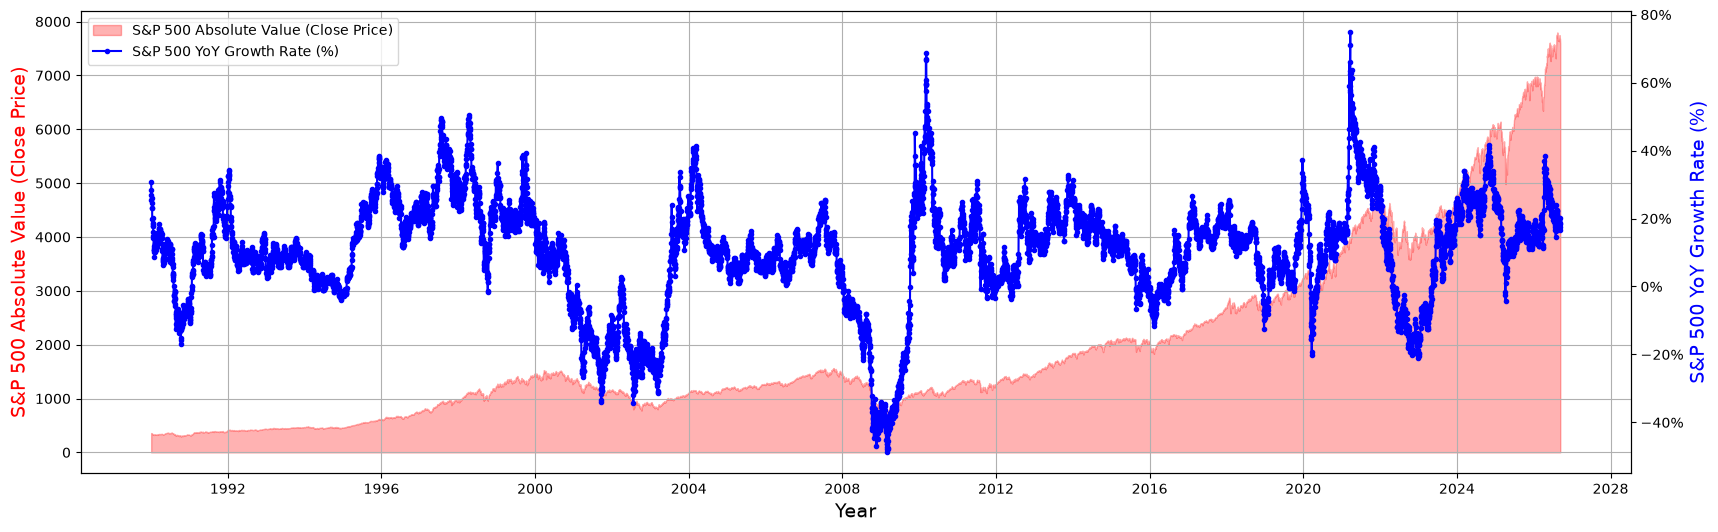

In [22]:
spx_index['spx_yoy'] = (spx_index.Close / spx_index.Close.shift(252)) - 1

# Re-truncate the DF after recalculating the YoY growth rate to ensure data consistency
spx_truncated = spx_index[spx_index.index >= '1990-01-01']

# S&P500 abs. vs. relative growth
fig, ax = plt.subplots(figsize=(20, 6))
plt.grid(True)

# Plotting area under S&P 500 Close price
ax.fill_between(spx_truncated.index, spx_truncated.Close, alpha=0.3, color='red', label='S&P 500 Absolute Value (Close Price)')

# Creating a secondary y-axis for S&P 500 YoY growth percentage
ax2 = ax.twinx()
ax2.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))
ax2.plot(spx_truncated.spx_yoy, color='blue', marker='.', label='S&P 500 YoY Growth Rate (%)')

# Setting labels and title
ax.set_xlabel('Year', fontsize=14)
ax.set_ylabel('S&P 500 Absolute Value (Close Price)', color='red', fontsize=14)
ax2.set_ylabel('S&P 500 YoY Growth Rate (%)', color='blue', fontsize=14)

# Adding legends
lines, labels = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc='upper left')

plt.show()

# 2) Data Sources for Stocks

## 2.1 OHLCV data daily - INDEXES

In [23]:
# INDEXES from Yahoo Finance
# DAX index (XETRA - XETRA Delayed Price. Currency in EUR)
# WEB: https://finance.yahoo.com/quote/%5EGDAXI
# Option 1: dax_daily = yf.download(tickers = ["^GDAXI"],
#                      period = "max",
#                      interval = "1d")

# Option 2 (preferred):
# Download data with Adj Close for more accurate price reflections
ticker_obj = yf.Ticker("^GDAXI")
dax_daily = ticker_obj.history(start=start)

In [24]:
dax_daily.tail()

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2026-09-07 00:00:00+02:00,26039.539062,26069.990234,25919.609375,26006.529297,35638000,0.0,0.0
2026-09-08 00:00:00+02:00,25897.220703,26026.779297,25799.660156,26007.630859,42236700,0.0,0.0
2026-09-09 00:00:00+02:00,25870.980469,25909.660156,25512.390625,25576.449219,53670200,0.0,0.0
2026-09-10 00:00:00+02:00,25555.660156,25612.089844,25361.150391,25361.150391,49936000,0.0,0.0
2026-09-11 00:00:00+02:00,25478.839844,25581.220703,25396.380859,25518.199219,0,0.0,0.0


In [25]:
# Normally 252 trading days in a year
dax_daily['adj_close_last_year'] = dax_daily['Close'].shift(252)
dax_daily['yoy_growth'] = (dax_daily['Close'] / dax_daily['adj_close_last_year']) - 1

In [26]:
dax_daily

,Open,High,Low,Close,Volume,Dividends,Stock Splits,adj_close_last_year,yoy_growth
Date,,,,,,,,,
1987-12-30 00:00:00+01:00,1005.190002,1005.190002,1005.190002,1005.190002,0,0.0,0.0,NaN,NaN
1988-01-04 00:00:00+01:00,956.489990,956.489990,956.489990,956.489990,0,0.0,0.0,NaN,NaN
1988-01-05 00:00:00+01:00,996.099976,996.099976,996.099976,996.099976,0,0.0,0.0,NaN,NaN
1988-01-06 00:00:00+01:00,1006.010010,1006.010010,1006.010010,1006.010010,0,0.0,0.0,NaN,NaN
1988-01-07 00:00:00+01:00,1014.469971,1014.469971,1014.469971,1014.469971,0,0.0,0.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...
2026-09-07 00:00:00+02:00,26039.539062,26069.990234,25919.609375,26006.529297,35638000,0.0,0.0,23807.130859,0.092384
2026-09-08 00:00:00+02:00,25897.220703,26026.779297,25799.660156,26007.630859,42236700,0.0,0.0,23718.449219,0.096515
2026-09-09 00:00:00+02:00,25870.980469,25909.660156,25512.390625,25576.449219,53670200,0.0,0.0,23632.949219,0.082237


<Axes: xlabel='Date'>

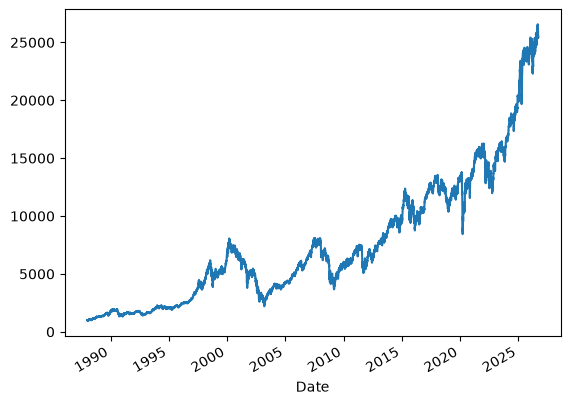

In [27]:
dax_daily.Close.plot.line()

In [28]:
# delayed 15 min : https://finance.yahoo.com/quote/%5ESPX/
# S&P 500 INDEX : Chicago Options - Chicago Options Delayed Price. Currency in USD
ticker_obj = yf.Ticker("^SPX")
snp500_daily = ticker_obj.history(start=start, interval="1d")

In [29]:
snp500_daily.tail()

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2026-09-04 00:00:00-04:00,7750.189941,7750.189941,7706.120117,7718.600098,4103570000,0.0,0.0
2026-09-08 00:00:00-04:00,7717.810059,7717.810059,7666.990234,7673.520020,4966930000,0.0,0.0
2026-09-09 00:00:00-04:00,7660.680176,7660.680176,7624.160156,7636.359863,4896940000,0.0,0.0
2026-09-10 00:00:00-04:00,7594.740234,7612.859863,7580.060059,7591.700195,4893500000,0.0,0.0
2026-09-11 00:00:00-04:00,7636.750000,7677.020020,7636.750000,7652.259766,691334760,0.0,0.0


In [30]:
# https://finance.yahoo.com/quote/%5EGSPC/
# SNP - SNP Real Time Price. Currency in USD
# https://www.investopedia.com/insights/introduction-to-stock-market-indices/

ticker_obj = yf.Ticker("^GSPC")
snp500_daily_non_delayed = ticker_obj.history(start=start, interval="1d")

In [31]:
snp500_daily_non_delayed.tail()

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2026-09-04 00:00:00-04:00,7750.189941,7750.189941,7706.120117,7718.600098,4103570000,0.0,0.0
2026-09-08 00:00:00-04:00,7717.810059,7717.810059,7666.990234,7673.520020,4966930000,0.0,0.0
2026-09-09 00:00:00-04:00,7660.680176,7660.680176,7624.160156,7636.359863,4896940000,0.0,0.0
2026-09-10 00:00:00-04:00,7594.740234,7612.859863,7580.060059,7591.700195,4893500000,0.0,0.0
2026-09-11 00:00:00-04:00,7636.750000,7677.020020,7636.750000,7660.799805,764971813,0.0,0.0


In [32]:
# Dow Jones Industrial Average: https://finance.yahoo.com/quote/%5EDJI?.tsrc=fin-srch

ticker_obj = yf.Ticker("^DJI")
dji_daily = ticker_obj.history(start=start, interval="1d")

dji_daily.tail()

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2026-09-04 00:00:00-04:00,53584.890625,53635.351562,53289.878906,53414.250000,381130000,0.0,0.0
2026-09-08 00:00:00-04:00,53110.449219,53110.449219,52721.621094,52786.070312,417970000,0.0,0.0
2026-09-09 00:00:00-04:00,52707.898438,52707.898438,52314.609375,52380.660156,403100000,0.0,0.0
2026-09-10 00:00:00-04:00,52291.851562,52291.851562,51962.710938,52064.101562,397900000,0.0,0.0
2026-09-11 00:00:00-04:00,52204.460938,52720.238281,52204.460938,52540.660156,121938565,0.0,0.0


## 2.2 OHLCV data daily - ETFs

In [33]:
# https://finance.yahoo.com/quote/VOO?.tsrc=fin-srch

ticker_obj = yf.Ticker("VOO")
voo_etf = ticker_obj.history(start=start, interval="1d")

voo_etf.tail()

,Open,High,Low,Close,Volume,Dividends,Stock Splits,Capital Gains
Date,,,,,,,,
2026-09-04 00:00:00-04:00,709.719971,710.450012,706.900024,708.010010,6806600,0.0,0.0,0.0
2026-09-08 00:00:00-04:00,706.979980,707.510010,703.369995,704.070007,7827600,0.0,0.0,0.0
2026-09-09 00:00:00-04:00,702.349976,702.710022,699.489990,700.869995,4293300,0.0,0.0,0.0
2026-09-10 00:00:00-04:00,696.780029,698.640015,695.539978,696.650024,18299200,0.0,0.0,0.0
2026-09-11 00:00:00-04:00,703.000000,704.495422,701.929993,703.330017,2337623,0.0,0.0,0.0


In [36]:
# ETFs
# WisdomTree India Earnings Fund (EPI)
# NYSEArca - Nasdaq Real Time Price. Currency in USD
# WEB: https://finance.yahoo.com/quote/EPI/history?p=EPI

ticker_obj = yf.Ticker("EPI")
epi_etf_daily = ticker_obj.history(start=start, interval="1d")

epi_etf_daily.head()

,Open,High,Low,Close,Volume,Dividends,Stock Splits,Capital Gains
Date,,,,,,,,
2008-02-26 00:00:00-05:00,21.249926,21.536865,21.069564,21.446684,813800,0.0,0.0,0.0
2008-02-27 00:00:00-05:00,21.422083,21.536860,21.200731,21.372894,881900,0.0,0.0,0.0
2008-02-28 00:00:00-05:00,21.299114,21.340106,21.036769,21.069563,1037000,0.0,0.0,0.0
2008-02-29 00:00:00-05:00,20.766223,20.766223,20.274326,20.339912,854700,0.0,0.0,0.0
2008-03-03 00:00:00-05:00,19.864419,19.946402,19.577479,19.790634,610000,0.0,0.0,0.0


In [37]:
print(epi_etf_daily.shape)

(4666, 8)


In [38]:
# find dividends impact on Close vs. Adj.Close
epi_etf_daily[epi_etf_daily.Dividends > 0].tail()

,Open,High,Low,Close,Volume,Dividends,Stock Splits,Capital Gains
Date,,,,,,,,
2021-12-27 00:00:00-05:00,33.577714,33.801816,33.577714,33.764465,379100,0.192,0.0,0.0
2022-03-25 00:00:00-04:00,33.563275,33.666313,33.432129,33.666313,584400,0.115,0.0,0.0
2022-06-24 00:00:00-04:00,29.420325,29.778746,29.370545,29.768789,387900,1.845,0.0,0.0
2023-06-26 00:00:00-04:00,34.020314,34.070182,33.960471,33.990395,634600,0.060,0.0,0.0
2024-12-26 00:00:00-05:00,45.840000,45.840000,45.700001,45.820000,685600,0.121,0.0,0.0


In [39]:
epi_etf_daily[(epi_etf_daily.index >= '2024-12-23') & (epi_etf_daily.index <= '2024-12-28') ]

,Open,High,Low,Close,Volume,Dividends,Stock Splits,Capital Gains
Date,,,,,,,,
2024-12-23 00:00:00-05:00,45.609761,45.879052,45.609761,45.869080,630400,0.000,0.0,0.0
2024-12-24 00:00:00-05:00,45.719475,45.928922,45.709503,45.899002,277100,0.000,0.0,0.0
2024-12-26 00:00:00-05:00,45.840000,45.840000,45.700001,45.820000,685600,0.121,0.0,0.0
2024-12-27 00:00:00-05:00,45.570000,45.650002,45.500000,45.639999,774900,0.000,0.0,0.0


In [40]:
# find dividends - diff for Close vs. Adj Close
# Open/Close for 06-25 diff is close to divs = 1.845 (~1.58 for Open and 1.3 for Close)
# HELP: https://help.yahoo.com/kb/SLN28256.html#:~:text=Adjusted%20close%20is%20the%20closing,Security%20Prices%20(CRSP)%20standards.
epi_etf_daily[(epi_etf_daily.index >='2024-12-23') & (epi_etf_daily.index <='2024-12-28')]

,Open,High,Low,Close,Volume,Dividends,Stock Splits,Capital Gains
Date,,,,,,,,
2024-12-23 00:00:00-05:00,45.609761,45.879052,45.609761,45.869080,630400,0.000,0.0,0.0
2024-12-24 00:00:00-05:00,45.719475,45.928922,45.709503,45.899002,277100,0.000,0.0,0.0
2024-12-26 00:00:00-05:00,45.840000,45.840000,45.700001,45.820000,685600,0.121,0.0,0.0
2024-12-27 00:00:00-05:00,45.570000,45.650002,45.500000,45.639999,774900,0.000,0.0,0.0


<Axes: title={'center': "EPI's etf stock price"}, xlabel='Date'>

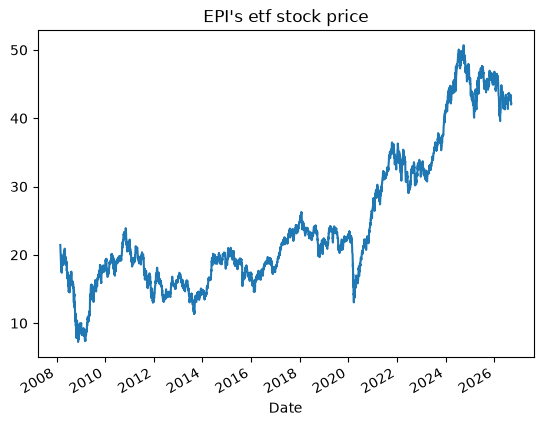

In [42]:
epi_etf_daily.Close.plot(title='EPI\'s etf stock price')

In [48]:
# get dividends, as a dataframe
epi = yf.Ticker("EPI")
epi.get_actions().head()

,Dividends
Date,
2008-12-22 00:00:00-05:00,0.091
2009-03-23 00:00:00-04:00,0.007
2009-06-22 00:00:00-04:00,0.002
2009-09-21 00:00:00-04:00,0.045
2009-12-21 00:00:00-05:00,0.006


In [51]:
# get dividends, as Series
epi.get_dividends().head()

Date
2008-12-22 09:30:00-05:00    0.091
2009-03-23 09:30:00-04:00    0.007
2009-06-22 09:30:00-04:00    0.002
2009-09-21 09:30:00-04:00    0.045
2009-12-21 09:30:00-05:00    0.006
Name: Dividends, dtype: float64

## 2.4 Macroeconomics

* some indicator examples: gold reserves vs. volatility

In [53]:
gold_reserves = pdr.DataReader('TRESEGCNM052N', 'fred', start=start)

<Axes: xlabel='DATE'>

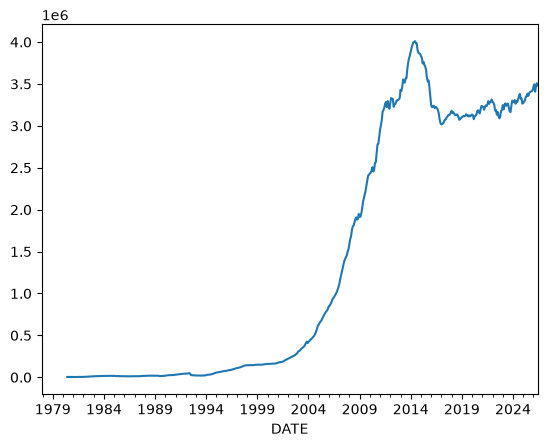

In [54]:
gold_reserves.TRESEGCNM052N.plot()

<Axes: xlabel='DATE'>

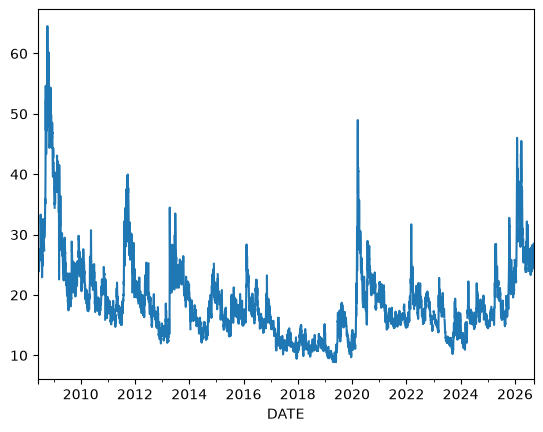

In [55]:
#  CBOE Gold ETF Volatility Index (GVZCLS)
# https://fred.stlouisfed.org/series/GVZCLS
gold_volatility = pdr.DataReader("GVZCLS", "fred", start=start)
gold_volatility.GVZCLS.plot()

<Axes: xlabel='DATE'>

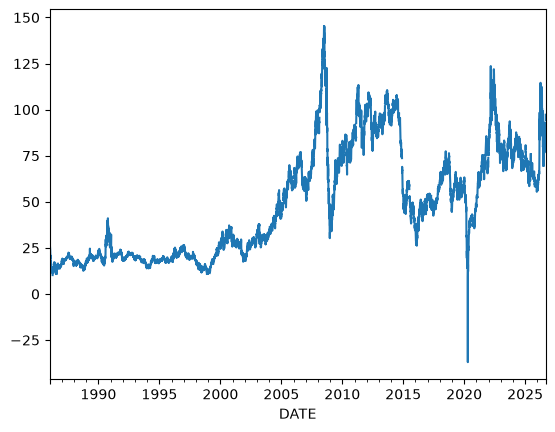

In [56]:
#  Crude Oil Prices: West Texas Intermediate (WTI) - Cushing, Oklahoma (DCOILWTICO)
# https://fred.stlouisfed.org/series/DCOILWTICO
oil_wti = pdr.DataReader("DCOILWTICO", "fred", start=start)
oil_wti.DCOILWTICO.plot()

<Axes: xlabel='DATE'>

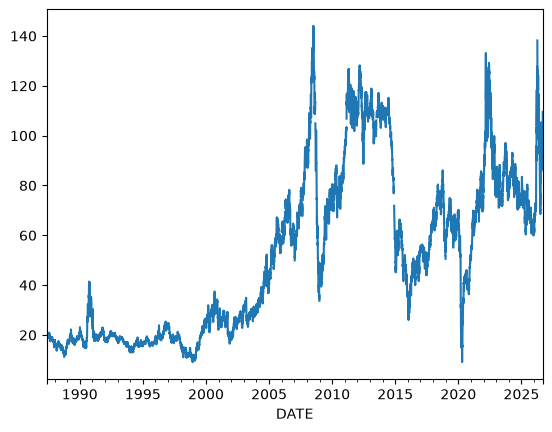

In [57]:
# Crude Oil Prices: Brent - Europe (DCOILBRENTEU)
# https://fred.stlouisfed.org/series/DCOILBRENTEU
oil_brent = pdr.DataReader("DCOILBRENTEU", "fred", start=start)
oil_brent.DCOILBRENTEU.plot()

In [58]:
# Web scraping for Macro
# can't call directly via pd.read_html() as it returns 403 (forbidden) --> need to do a bit of work, but still no Selenium
# https://tradingeconomics.com/united-states/indicators
import requests
from bs4 import BeautifulSoup

url = "https://tradingeconomics.com/united-states/indicators"
headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/58.0.3029.110 Safari/537.3"
}

response = requests.get(url, headers=headers)

In [60]:

# Check if the request was successful (status code 200)
if response.status_code == 200:
    # Parse the HTML content of the webpage
    soup = BeautifulSoup(response.content, "html.parser")

    # You need to be able to find this table tag and read all behind it
    # Find the div with class "table-responsive"
    table_div = soup.find("div", class_="table-responsive")

    # Extract the table within the div
    table = table_div.find("table")

    from io import StringIO


    dfs = pd.read_html(StringIO(response.text))
    df = dfs[0]
    print(df)
else:
    print("Failed to retrieve data from the webpage.")

                  Unnamed: 0     Last  Previous  Highest    Lowest  \
0                   Currency    99.07     99.05   165.00     70.70   
1               Stock Market  7669.00   7592.00  7817.00      4.40   
2            GDP Growth Rate     1.50      2.10    34.90    -28.00   
3     GDP Annual Growth Rate     2.10      2.70    13.40     -7.40   
4          Unemployment Rate     4.10      4.10    14.80      2.50   
5          Non Farm Payrolls   162.00     21.00  4631.00 -20469.00   
6             Inflation Rate     3.40      3.40    23.70    -15.80   
7         Inflation Rate MoM     0.40      0.10     2.00     -1.80   
8              Interest Rate     3.75      3.75    20.00      0.25   
9           Balance of Trade   -88.58    -71.18     1.95   -133.00   
10           Current Account  -227.00   -221.00     9.96   -438.00   
11    Current Account to GDP    -3.60     -4.00     0.20     -6.00   
12    Government Debt to GDP   123.00    122.00   126.00     31.80   
13         Governmen

In [61]:
df

,Unnamed: 0,Last,Previous,Highest,Lowest,Unnamed: 5,Unnamed: 6
0,Currency,99.07,99.05,165.00,70.70,NaN,Sep/26
1,Stock Market,7669.00,7592.00,7817.00,4.40,points,Sep/26
2,GDP Growth Rate,1.50,2.10,34.90,-28.00,percent,Jun/26
3,GDP Annual Growth Rate,2.10,2.70,13.40,-7.40,percent,Jun/26
4,Unemployment Rate,4.10,4.10,14.80,2.50,percent,Aug/26
5,Non Farm Payrolls,162.00,21.00,4631.00,-20469.00,Thousand,Aug/26
6,Inflation Rate,3.40,3.40,23.70,-15.80,percent,Aug/26
7,Inflation Rate MoM,0.40,0.10,2.00,-1.80,percent,Aug/26
8,Interest Rate,3.75,3.75,20.00,0.25,percent,Aug/26
9,Balance of Trade,-88.58,-71.18,1.95,-133.00,USD Billion,Jul/26


## 2.5) Financial reporting - EDGAR (in Yahoo)

In [62]:
# check for NVDA
nvda = yf.Ticker("NVDA")

In [64]:
# yearly financials for last 4 years
nvda.financials.T

,Tax Effect Of Unusual Items,Tax Rate For Calcs,Normalized EBITDA,Total Unusual Items,Total Unusual Items Excluding Goodwill,Net Income From Continuing Operation Net Minority Interest,Reconciled Depreciation,Reconciled Cost Of Revenue,EBITDA,EBIT,...,Interest Expense Non Operating,Interest Income Non Operating,Operating Income,Operating Expense,Research And Development,Selling General And Administration,Gross Profit,Cost Of Revenue,Total Revenue,Operating Revenue
2026-01-31,0.0,0.151170,1.445520e+11,NaN,NaN,1.200670e+11,2.843000e+09,6.247500e+10,1.445520e+11,1.417090e+11,...,259000000.0,2.300000e+09,1.303870e+11,2.307600e+10,1.849700e+10,4.579000e+09,1.534630e+11,6.247500e+10,2.159380e+11,2.159380e+11
2025-01-31,0.0,0.132649,8.613700e+10,0.000000e+00,0.000000e+00,7.288000e+10,1.864000e+09,3.263900e+10,8.613700e+10,8.427300e+10,...,247000000.0,1.786000e+09,8.145300e+10,1.640500e+10,1.291400e+10,3.491000e+09,9.785800e+10,3.263900e+10,1.304970e+11,1.304970e+11
2024-01-31,0.0,0.120000,3.558300e+10,0.000000e+00,0.000000e+00,2.976000e+10,1.508000e+09,1.662100e+10,3.558300e+10,3.407500e+10,...,257000000.0,8.660000e+08,3.297200e+10,1.132900e+10,8.675000e+09,2.654000e+09,4.430100e+10,1.662100e+10,6.092200e+10,6.092200e+10
2023-01-31,-284130000.0,0.210000,7.339000e+09,-1.353000e+09,-1.353000e+09,4.368000e+09,1.543000e+09,1.161800e+10,5.986000e+09,4.443000e+09,...,262000000.0,2.670000e+08,5.577000e+09,9.779000e+09,7.339000e+09,2.440000e+09,1.535600e+10,1.161800e+10,2.697400e+10,2.697400e+10
2022-01-31,NaN,NaN,NaN,0.000000e+00,0.000000e+00,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [65]:
# balance sheet
nvda.balance_sheet

,2026-01-31,2025-01-31,2024-01-31,2023-01-31,2022-01-31
Ordinary Shares Number,2.430400e+10,2.447700e+10,2.464000e+10,2.466137e+10,NaN
Share Issued,2.430400e+10,2.447700e+10,2.464000e+10,2.466137e+10,NaN
Net Debt,NaN,NaN,2.429000e+09,7.564000e+09,8.956000e+09
Total Debt,1.104000e+10,9.982000e+09,1.105600e+10,1.203100e+10,NaN
Tangible Book Value,1.331550e+11,7.333200e+10,3.743600e+10,1.605300e+10,NaN
...,...,...,...,...,...
Receivables,3.846600e+10,2.306500e+10,9.999000e+09,3.827000e+09,NaN
Accounts Receivable,3.846600e+10,2.306500e+10,9.999000e+09,3.827000e+09,NaN
Cash Cash Equivalents And Short Term Investments,6.255600e+10,4.321000e+10,2.598400e+10,1.329600e+10,NaN
Other Short Term Investments,5.195100e+10,3.462100e+10,1.870400e+10,9.907000e+09,NaN


In [66]:
# basic info:
nvda.fast_info

lazy-loading dict with keys = ['currency', 'dayHigh', 'dayLow', 'exchange', 'fiftyDayAverage', 'lastPrice', 'lastVolume', 'marketCap', 'open', 'previousClose', 'quoteType', 'regularMarketPreviousClose', 'shares', 'tenDayAverageVolume', 'threeMonthAverageVolume', 'timezone', 'twoHundredDayAverage', 'yearChange', 'yearHigh', 'yearLow']

In [ ]:
# marketCap is useful, but check when it was updated
nvda.fast_info['marketCap']/1e9

5285.053772094727

## 2.6 Web Scraping - company info for clustering

In [70]:
# ask chatGPT: emulate clicking the link and downloading the content
import requests
from bs4 import BeautifulSoup

# URL of the webpage
url = "https://companiesmarketcap.com/"

# Define headers with a user-agent to mimic a web browser
headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/58.0.3029.110 Safari/537.3"
}

# Send a GET request to the URL with headers
response = requests.get(url, headers=headers)

# Check if the request was successful (status code 200)
if response.status_code == 200:
    # Parse the HTML content of the webpage
    soup = BeautifulSoup(response.content, "html.parser")

    # Find the download link within the webpage
    download_link = soup.find("a", {"rel": "nofollow", "href": "?download=csv"})

    # If the download link is found
    if download_link:
        # Extract the href attribute which contains the actual download link
        download_url = 'https://companiesmarketcap.com/'+download_link["href"]

        # Download the CSV file using the obtained download URL
        download_response = requests.get(download_url, headers=headers)

        # Check if the download request was successful
        if download_response.status_code == 200:
            # Save the content of the response to a local file
            with open("global_stocks.csv", "wb") as f:
                f.write(download_response.content)
            print("CSV file downloaded successfully.")
        else:
            print("Failed to download the CSV file.")
    else:
        print("Download link not found on the webpage.")
else:
    print("Failed to retrieve data from the webpage.")

CSV file downloaded successfully.


In [74]:
global_stocks = pd.read_csv("global_stocks.csv")
global_stocks["marketcap"] = global_stocks["marketcap"]/1e9
global_stocks.head(10)

,Rank,Name,Symbol,marketcap,price (USD),country
0,1,NVIDIA,NVDA,5287.968244,218.99100,United States
1,2,Apple,AAPL,4878.834336,334.30000,United States
2,3,Alphabet (Google),GOOG,4127.786795,337.51500,United States
3,4,Microsoft,MSFT,3679.358550,495.50000,United States
4,5,Amazon,AMZN,2758.815252,255.77000,United States
5,6,TSMC,TSM,2244.446519,432.75000,Taiwan
6,7,SpaceX,SPCX,1958.548865,148.58000,United States
7,8,Broadcom,AVGO,1739.320328,364.36000,United States
8,9,Saudi Aramco,2222.SR,1683.786162,6.96046,Saudi Arabia
9,10,Meta Platforms (Facebook),META,1651.522666,648.29000,United States


In [75]:
global_stocks.info()

<class 'pandas.DataFrame'>
RangeIndex: 11329 entries, 0 to 11328
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Rank         11329 non-null  int64  
 1   Name         11329 non-null  str    
 2   Symbol       11328 non-null  str    
 3   marketcap    11329 non-null  float64
 4   price (USD)  11329 non-null  float64
 5   country      11329 non-null  str    
dtypes: float64(2), int64(1), str(3)
memory usage: 531.2 KB
